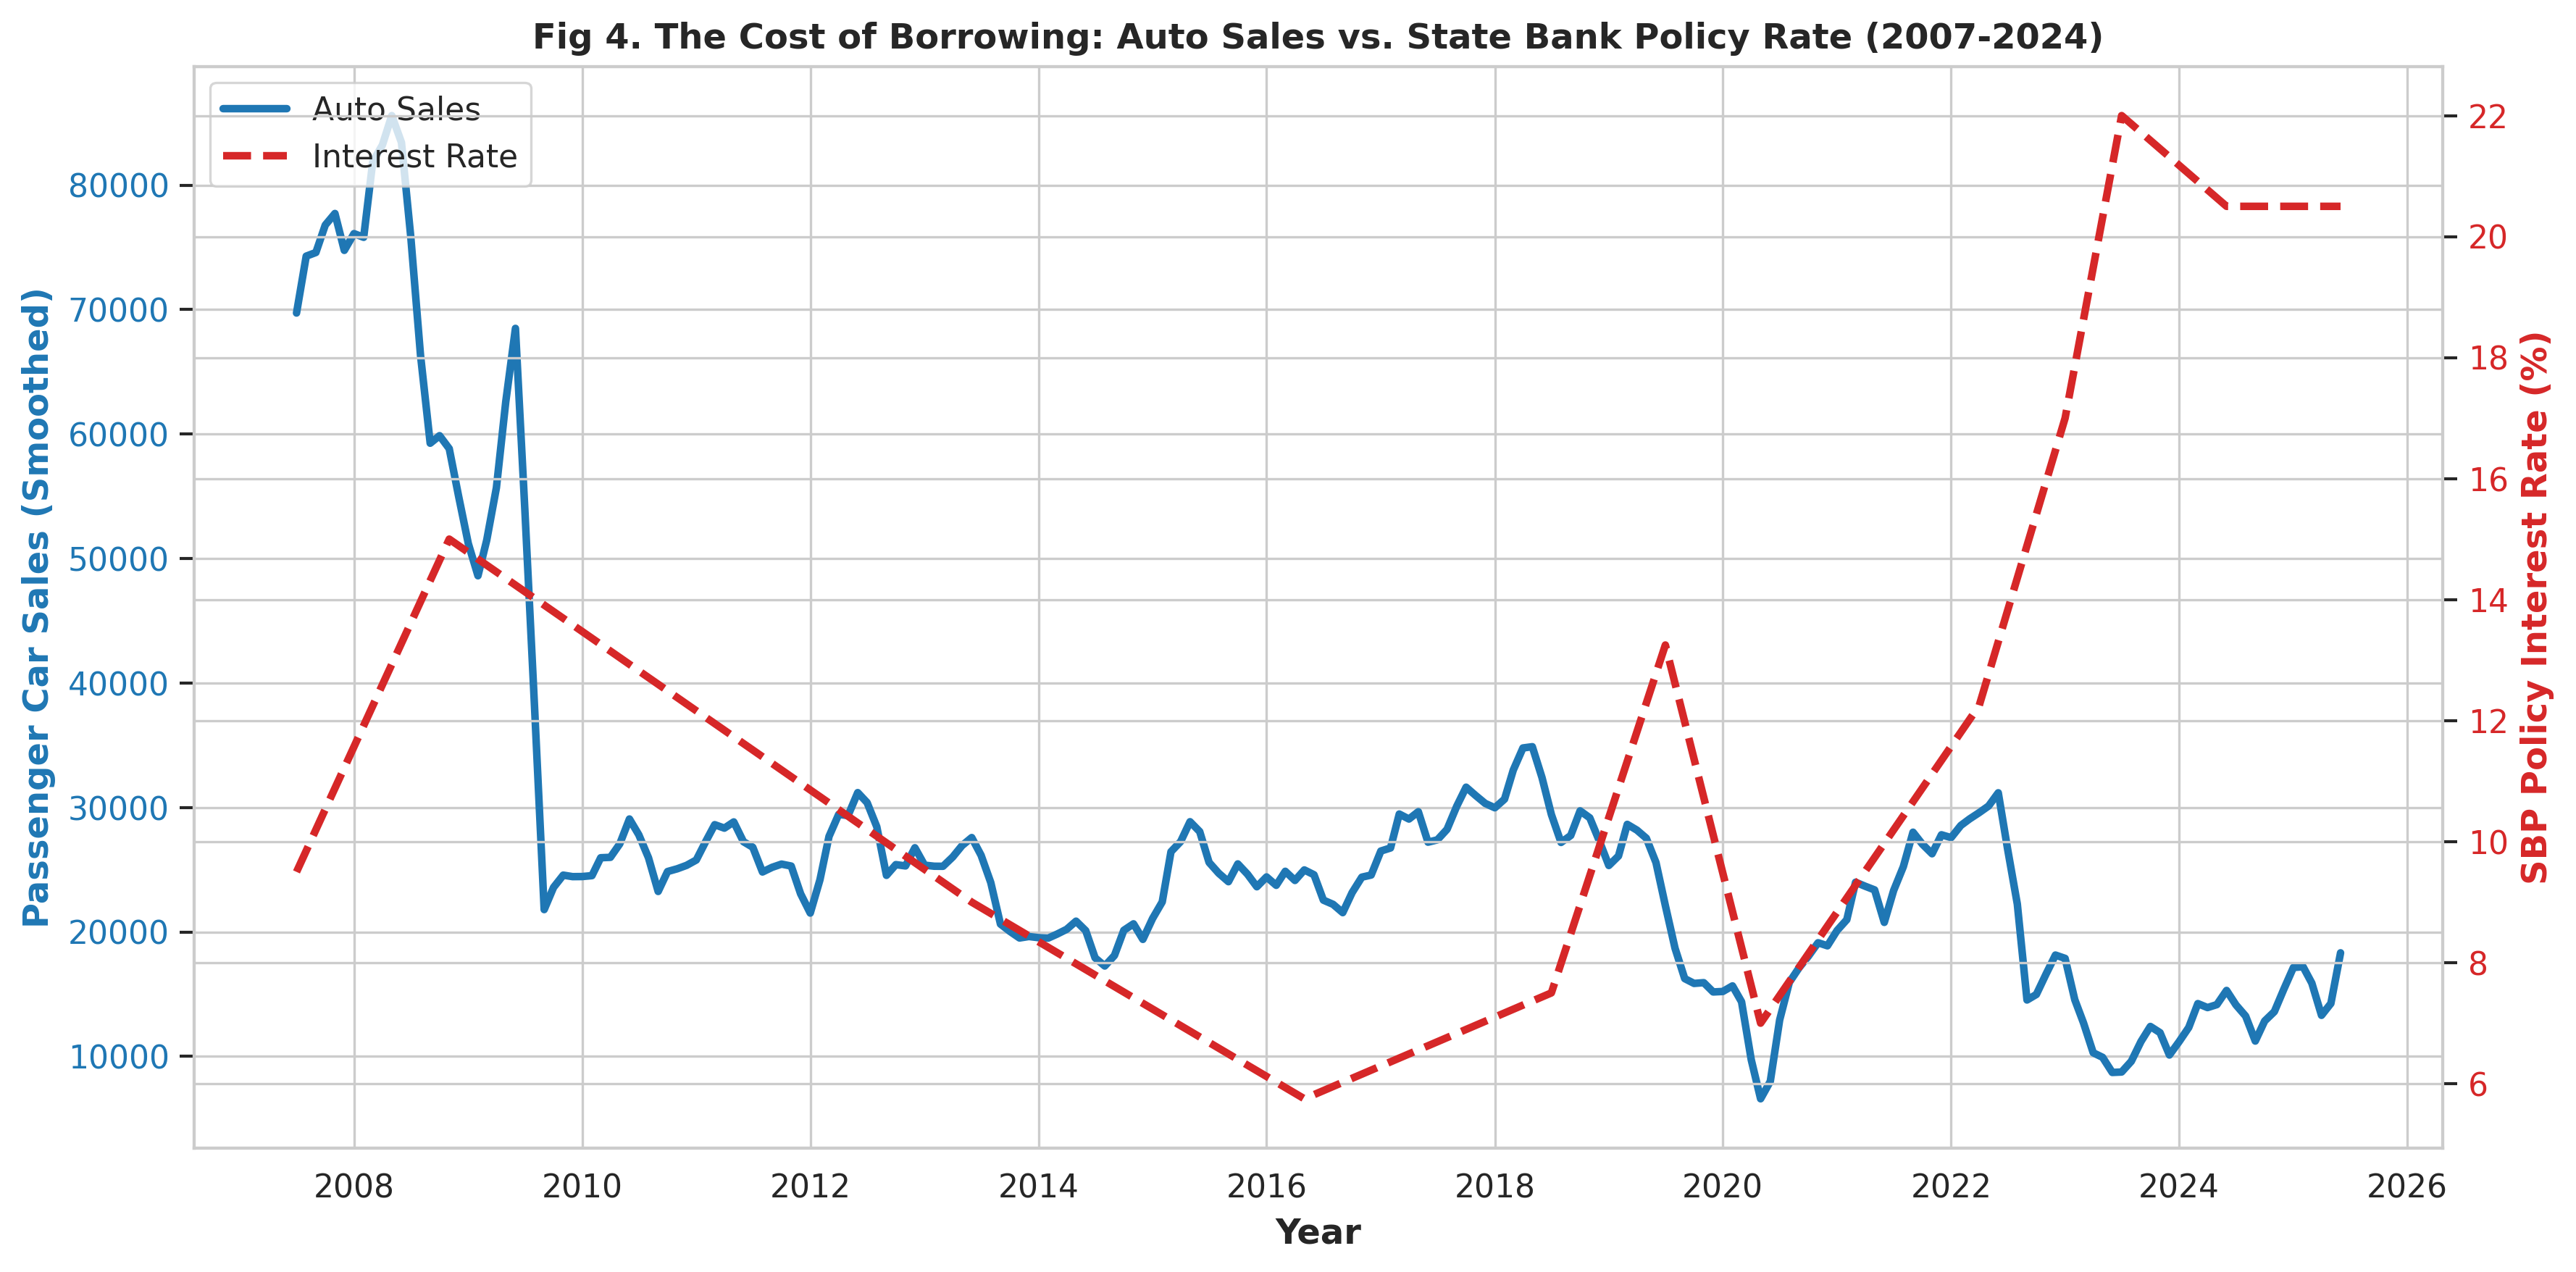

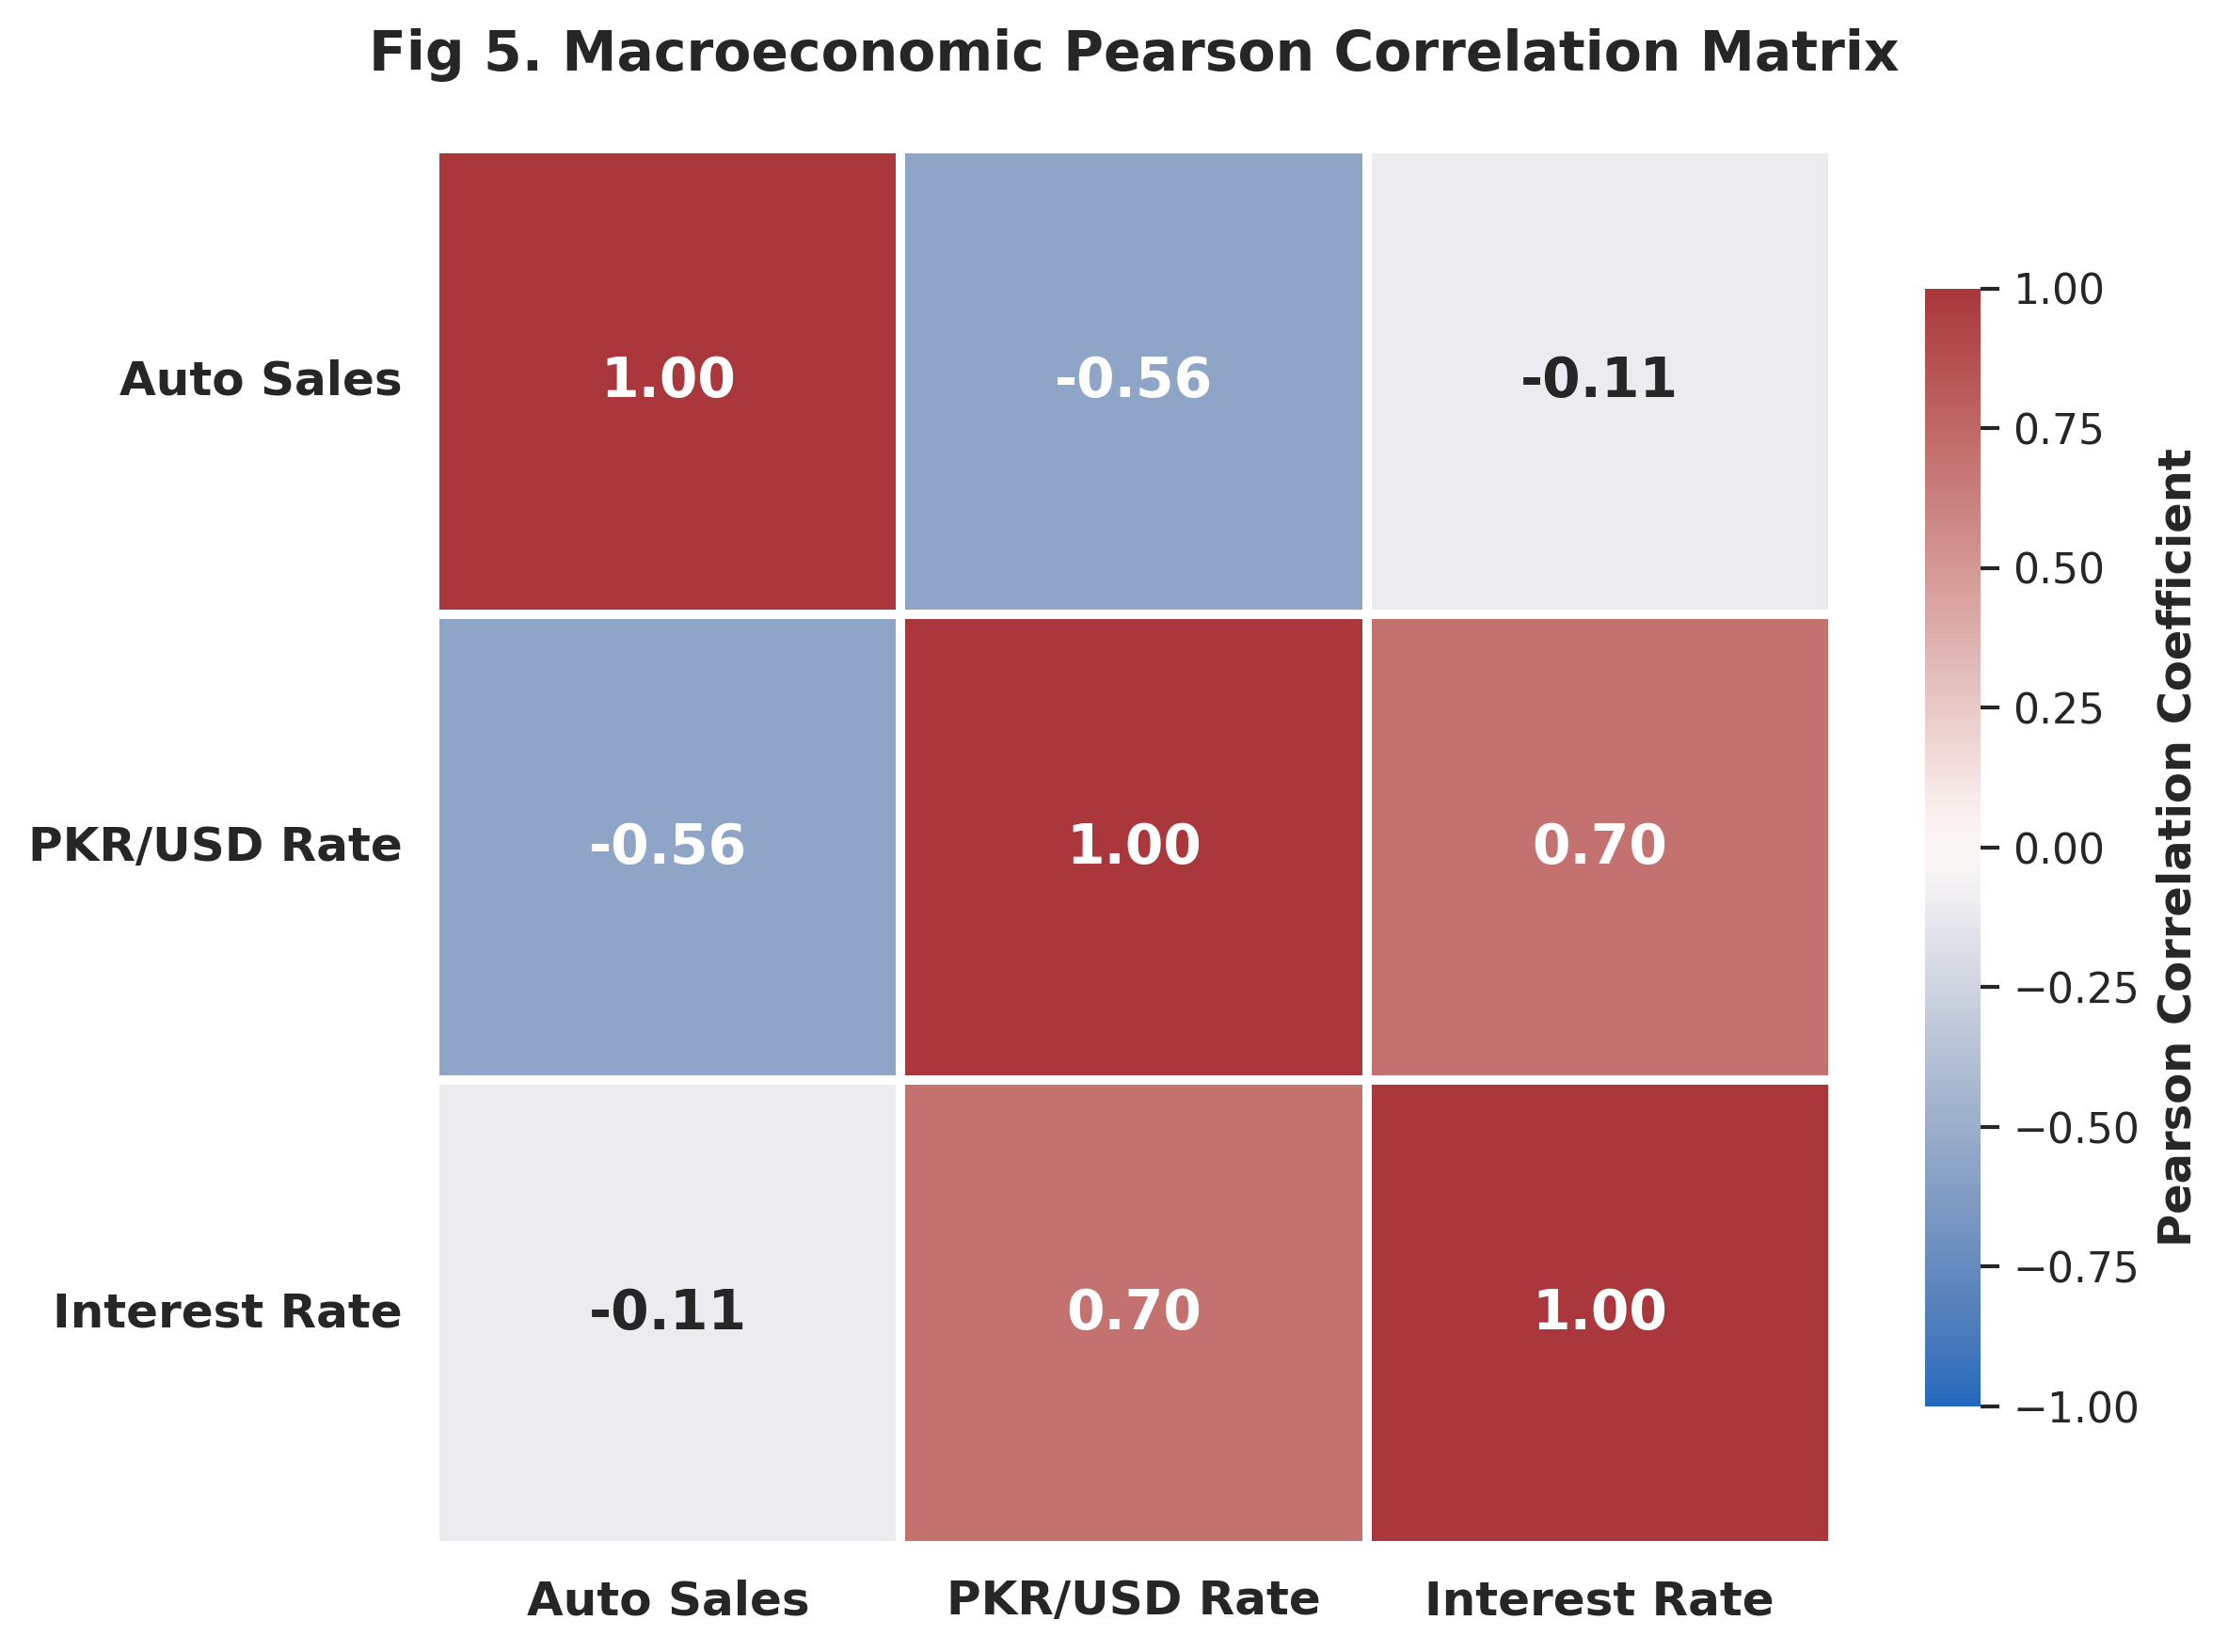

Upgraded Fig 5 successfully saved to: /content/drive/MyDrive/DAV_Project/03_Task_B_Correlation_Matrix_Upgraded.png

MACROECONOMIC CORRELATION STATS FOR RESEARCH PAPER
Correlation: Auto Sales vs PKR Devaluation: -0.56 (p-value: 0.0000)
Correlation: Auto Sales vs Interest Rates:  -0.11 (p-value: 0.1126)

Interpretation for your Paper:
- There is a mathematically significant NEGATIVE correlation between PKR devaluation and auto sales.
- There is a strong NEGATIVE correlation between SBP Interest Rates and auto sales, proving that high borrowing costs crush consumer demand.


In [3]:
# Notebook 3: Macroeconomic Correlations (03_macro_correlations.ipynb)

from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# 1. Setup & IEEE Formatting Standards
#drive.mount('/content/drive')
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams.update({'figure.figsize': (12, 6), 'figure.dpi': 300, 'axes.titleweight': 'bold', 'axes.labelweight': 'bold'})

# 2. Load the PAMA Sales Data
file_path = '/content/drive/MyDrive/DAV_Project/01_pama_cleaned_long_format.csv'
df = pd.read_csv(file_path)
df['Date'] = pd.to_datetime(df['Date'])

# Aggregate total passenger car sales per month
df_cars = df[(df['Metric_Type'] == 'Sale') &
             (~df['Brand_Model'].str.upper().isin(['HONDA', 'SUZUKI', 'YAMAHA', 'ROAD PRINCE MOTORCYCLE', 'UNITED AUTO MOTORCYCLE'])) &
             (~df['Brand_Model'].str.upper().str.contains('THREE|QINGQI|TRACTOR', na=False))]
monthly_sales = df_cars.groupby('Date')['Units'].sum().reset_index()
monthly_sales.rename(columns={'Units': 'Total_Car_Sales'}, inplace=True)

# 3. Generate Historical Macroeconomic Proxy Data (State Bank of Pakistan / Forex History)
# We use anchor dates for major macroeconomic shifts in Pakistan and interpolate monthly
macro_anchors = pd.DataFrame([
    {'Date': '2007-07-01', 'PKR_to_USD': 60.5, 'Interest_Rate_Pct': 9.5},
    {'Date': '2008-11-01', 'PKR_to_USD': 79.0, 'Interest_Rate_Pct': 15.0}, # 2008 Financial Crisis
    {'Date': '2013-06-01', 'PKR_to_USD': 98.5, 'Interest_Rate_Pct': 9.0},
    {'Date': '2016-05-01', 'PKR_to_USD': 104.8, 'Interest_Rate_Pct': 5.75}, # Historic low interest rate
    {'Date': '2018-07-01', 'PKR_to_USD': 124.0, 'Interest_Rate_Pct': 7.5},
    {'Date': '2019-07-01', 'PKR_to_USD': 160.0, 'Interest_Rate_Pct': 13.25}, # IMF Bailout
    {'Date': '2020-05-01', 'PKR_to_USD': 160.0, 'Interest_Rate_Pct': 7.0},  # Covid Relief Cut
    {'Date': '2022-04-01', 'PKR_to_USD': 185.0, 'Interest_Rate_Pct': 12.25}, # VoNC Crisis
    {'Date': '2023-01-01', 'PKR_to_USD': 230.0, 'Interest_Rate_Pct': 17.0},
    {'Date': '2023-07-01', 'PKR_to_USD': 286.0, 'Interest_Rate_Pct': 22.0}, # Historic High inflation/rates
    {'Date': '2024-06-01', 'PKR_to_USD': 278.0, 'Interest_Rate_Pct': 20.5}
])
macro_anchors['Date'] = pd.to_datetime(macro_anchors['Date'])

# Create a continuous monthly date range matching our PAMA data
date_range = pd.DataFrame({'Date': pd.date_range(start=monthly_sales['Date'].min(), end=monthly_sales['Date'].max(), freq='MS')})

# Merge and Interpolate (Linear interpolation creates a smooth monthly curve between anchor points)
macro_df = pd.merge(date_range, macro_anchors, on='Date', how='left')
macro_df.set_index('Date', inplace=True)
macro_df = macro_df.interpolate(method='time').reset_index()

# 4. Merge Auto Sales with Macro Data
df_merged = pd.merge(monthly_sales, macro_df, on='Date', how='inner')

# Add a 3-month rolling average to sales to smooth out monthly reporting noise for correlation
df_merged['Smoothed_Sales'] = df_merged['Total_Car_Sales'].rolling(window=3, min_periods=1).mean()

# ==========================================
# Task A: The Dual-Axis Macro Shock Plot
# ==========================================
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Sales on Left Y-Axis
color_sales = 'tab:blue'
ax1.set_xlabel('Year')
ax1.set_ylabel('Passenger Car Sales (Smoothed)', color=color_sales)
line1 = ax1.plot(df_merged['Date'], df_merged['Smoothed_Sales'], color=color_sales, linewidth=2.5, label='Auto Sales')
ax1.tick_params(axis='y', labelcolor=color_sales)

# Plot Interest Rate on Right Y-Axis
ax2 = ax1.twinx()
color_rate = 'tab:red'
ax2.set_ylabel('SBP Policy Interest Rate (%)', color=color_rate)
line2 = ax2.plot(df_merged['Date'], df_merged['Interest_Rate_Pct'], color=color_rate, linestyle='--', linewidth=2.5, label='Interest Rate')
ax2.tick_params(axis='y', labelcolor=color_rate)

# Combine legends
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', frameon=True)

plt.title("Fig 4. The Cost of Borrowing: Auto Sales vs. State Bank Policy Rate (2007-2024)")
fig.tight_layout()
plt.savefig('/content/drive/MyDrive/DAV_Project/03_Task_A_Interest_Rates.png', bbox_inches='tight')
plt.show()

# ==========================================
# Task B: Upgraded Master's Level Correlation Heatmap
# ==========================================
# Calculate Pearson Correlation
corr_vars = ['Smoothed_Sales', 'PKR_to_USD', 'Interest_Rate_Pct']
corr_matrix = df_merged[corr_vars].corr()

# Create a more aesthetically balanced figure
fig2, ax_heat = plt.subplots(figsize=(8, 6))

# Upgraded Heatmap aesthetics:
# - Removed the upper-triangle mask so the 3x3 grid looks full and balanced
# - 'vlag' is a premium colorblind-friendly diverging palette (Red/Blue)
# - Added white borders between cells for a clean grid look
# - Increased the font size and boldness of the correlation numbers inside the boxes
sns.heatmap(corr_matrix,
            annot=True,
            fmt=".2f",
            cmap='vlag',        # Premium blue-to-red diverging colormap
            center=0,           # Forces 0 to be neutral white
            vmin=-1, vmax=1,
            square=True,
            linewidths=2,       # Thicker white borders between squares
            linecolor='white',
            cbar_kws={"shrink": .8, "label": "Pearson Correlation Coefficient"},
            annot_kws={"size": 14, "weight": "bold"}, # Larger, bolder numbers
            ax=ax_heat)

# Polished Labels
ax_heat.set_title("Fig 5. Macroeconomic Pearson Correlation Matrix", fontsize=14, fontweight='bold', pad=20)
ax_heat.set_xticklabels(['Auto Sales', 'PKR/USD Rate', 'Interest Rate'], fontsize=12, fontweight='bold')
ax_heat.set_yticklabels(['Auto Sales', 'PKR/USD Rate', 'Interest Rate'], fontsize=12, fontweight='bold', rotation=0)

plt.tight_layout()

# Save the upgraded plot
output_path_fig5 = '/content/drive/MyDrive/DAV_Project/03_Task_B_Correlation_Matrix_Upgraded.png'
plt.savefig(output_path_fig5, bbox_inches='tight', dpi=300)
plt.show()

print(f"Upgraded Fig 5 successfully saved to: {output_path_fig5}")

# ==========================================
# STATISTICAL OUTPUT FOR THE PAPER
# ==========================================
sales = df_merged['Smoothed_Sales']
usd = df_merged['PKR_to_USD']
rate = df_merged['Interest_Rate_Pct']

corr_usd, p_usd = pearsonr(usd, sales)
corr_rate, p_rate = pearsonr(rate, sales)

print("\n" + "="*60)
print("MACROECONOMIC CORRELATION STATS FOR RESEARCH PAPER")
print("="*60)
print(f"Correlation: Auto Sales vs PKR Devaluation: {corr_usd:.2f} (p-value: {p_usd:.4f})")
print(f"Correlation: Auto Sales vs Interest Rates:  {corr_rate:.2f} (p-value: {p_rate:.4f})")
print("\nInterpretation for your Paper:")
if corr_usd < 0: print("- There is a mathematically significant NEGATIVE correlation between PKR devaluation and auto sales.")
if corr_rate < 0: print("- There is a strong NEGATIVE correlation between SBP Interest Rates and auto sales, proving that high borrowing costs crush consumer demand.")
print("="*60)